[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/notebooks/02_WalkForward_Simulation/Walk_Forward_Backtest_Equity_Bond.ipynb)








# Walk-Forward Simulation: Systematic Regime-Based Strategy

This notebook marks the transition from descriptive in-sample research to out-of-sample systematic application. Having identified the structural market regimes in the previous stage, we now implement a fully autonomous investment strategy that replicates real-world conditions.

The objective is to evaluate whether macro-economic signals, integrated through a Hidden Markov Model with Time-Varying Transition Probabilities (HMM-TVTP), can generate alpha by dynamically adjusting the stock-bond allocation.

# Connection to GitHub

In [1]:
import os
import sys

# 1. Environment check
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone the repository
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Move to the project directory
    os.chdir(repo_name)

    # 4. Add the project path to the system path for importing .py modules
    sys.path.append(os.getcwd())

    print(f"Current working directory: {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 966, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 966 (delta 147), reused 73 (delta 73), pack-reused 751 (from 2)
Receiving objects: 100% (966/966), 21.13 MiB | 17.21 MiB/s, done.
Resolving deltas: 100% (462/462), done.
Répertoire actuel : /content/CorrelationEquityBond


# Installation of the `ssm` library via the Git repository

In [2]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-4eciia29
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-4eciia29
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614353 sha256=3548271b5885ae49c8ce5b02be3e01e8360a2fbeec8ed4d433ed87b83464d8e8
  Stored in directory: /tmp/pip-ephem-wheel-cache-ybuhmjus/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Data preparation

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
MACRO_VARS = ["inflation_yoy", "credit_spread_diff"]
asset_names = ["S&P", "T-bond 10y"]

# Feature Engineering Macro
df['inflation_yoy'] = df['CPI'].pct_change(12)
df['credit_spread'] = df['BAA'] - df['AAA']
df['credit_spread_diff'] = df['credit_spread'].diff(2)

df[MACRO_VARS] = df[MACRO_VARS].shift(1) # causality

SEED = 120
np.random.seed(SEED)


In [24]:
df.head()

,Price,Dividend,Earnings,CPI,Rate GS10,Real Price,Real Dividend,Real Total Return,Real Earnings,Real TR Scaled Earnings,...,UNRATE,DGS10,M2SL,USRECD,PPIACO,AAA_Log_Return,BAA_Log_Return,inflation_yoy,credit_spread,credit_spread_diff
Date,,,,,,,,,,,,,,,,,,,,,
1934-01-01,10.54,0.44,0.44,13.2,3.12,258.15,10.80,7283.51,10.88,306.96,...,NaN,NaN,NaN,0.0,12.4,NaN,NaN,NaN,2.66,NaN
1934-02-01,11.32,0.44,0.45,13.3,3.09,275.17,10.74,7788.94,10.90,308.46,...,NaN,NaN,NaN,0.0,12.7,-0.035091,-0.111561,NaN,2.07,NaN
1934-03-01,10.74,0.44,0.45,13.3,3.07,261.07,10.76,7415.24,11.00,312.42,...,NaN,NaN,NaN,0.0,12.7,-0.016807,-0.001596,NaN,2.13,NaN
1934-04-01,10.92,0.44,0.46,13.3,3.04,265.45,10.78,7565.02,11.10,316.39,...,NaN,NaN,NaN,0.0,12.7,-0.014634,-0.040755,NaN,1.94,-0.53
1934-05-01,9.81,0.44,0.46,13.3,3.01,238.47,10.80,6821.69,11.20,320.43,...,NaN,NaN,NaN,0.0,12.7,-0.014852,0.006634,NaN,2.04,-0.13


# Walk-Forward Inference

In [25]:
from src.stock_bond_correlation.models.HMMMarketWithMacroTransitionsRegimeDetector import HMMMarketWithMacroTransitionsRegimeDetector
from src.stock_bond_correlation.walk_forward_regime_inference.GenericHMMBacktester import GenericHMMBacktester
from src.stock_bond_correlation.strategy.strategy_backtest.StrategySimulator import StrategySimulator
from src.stock_bond_correlation.diagnostics.explainability_IG.TransitionExplainer import TransitionExplainer
from src.stock_bond_correlation.strategy.utils.performance import get_metrics
from src.stock_bond_correlation.visualization.performance_reporter import plot_equity_curves, plot_allocation_stack

import matplotlib.pyplot as plt


In [26]:
# =============================================================================
# 1. MACRO BACKTEST CONFIGURATION
# =============================================================================
n_regimes_max = 4

# =============================================================================
# 2. DETECTOR SELECTION (WITH MACRO VARIABLES)
# =============================================================================
# Switching to HMM TVTP
market_detector = HMMMarketWithMacroTransitionsRegimeDetector(
    n_regimes=n_regimes_max,
    n_dim=len(ASSET_VARS),
    n_input=len(MACRO_VARS),  # required for transition matrix dimensions
    random_state=SEED,
    # High kappa to prevent excessively frequent regime switching
    transition_kwargs={"kappa": 30, "l2_penalty": 1, "alpha": 1.3}
)

# =============================================================================
# 3. BACKTEST INITIALIZATION (WITH INPUT VARIABLES)
# =============================================================================
backtester = GenericHMMBacktester(
    detector=market_detector,
    data_df=df,
    obs_vars=ASSET_VARS,
    asset_vars=ASSET_VARS,
    input_vars=MACRO_VARS,
    refit_freq=3,
    reset_total_freq=6,
    scaling_factor=100.0,
    # Consistency constraints
    sig_threshold=0.4,
    min_duration=3,
    min_freq=0.02,
    sig_max_cond_number=1e7,
    min_confidence=0.7,
    n_jobs=-1,
)

# =============================================================================
# 4. RUN BACKTEST
# =============================================================================
print(f"Running MACRO backtest over {len(df.index[df.index >= '1995-01-01'])} months...")
# Starting in 2007 to ensure a solid expansion history
backtester.run(start_date="1995-01-01", end_date="2026-05-01")

Running MACRO backtest over 367 months...


  1%|          | 4/367 [00:26<30:15,  5.00s/it]  


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
▶ DATE : 1995-01-01 | MODE : Reset-Random
  [MONTHLY REALIZED RETS] Stock_Log_Return:  +2.42% | Bond_Log_Return:  +0.86%
  [ROLLING 12M STATS]     V_SP:  6.0% | V_BN:  5.5% | RHO:  0.67
  [INPUTS MACRO X_t]      inflation_yoy: -1.00 | credit_spread_diff: +0.05
  --------------------------------------------------------------------------------------------------------------
  REGIME   | PROBA  | RHO   | V_SP   | V_BN   | W_inflatio   | W_credit_s  
  --------------------------------------------------------------------------------------------------------------
  Reg 0    |  4.7% |  0.34 | 10.3% |  3.2% |        -0.15 |        +0.36
  Reg 1    |  1.1% |  0.39 | 18.7% |  5.2% |        +0.39 |        +0.53
  Reg 2    |  0.3% |  0.19 | 16.9% | 13.8% |        +0.62 |        -0.12
  Reg 3    | 93.9% |  0.50 |  8.0% |  6.5% |        -0.86 |        -0.77
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  3%|▎         | 10/367 [00:48<21:23,  3.60s/it]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
▶ DATE : 1995-07-01 | MODE : Reset-Random
  [MONTHLY REALIZED RETS] Stock_Log_Return:  +3.49% | Bond_Log_Return:  -0.29%
  [ROLLING 12M STATS]     V_SP:  6.0% | V_BN:  6.2% | RHO:  0.58
  [INPUTS MACRO X_t]      inflation_yoy: -0.87 | credit_spread_diff: +0.15
  --------------------------------------------------------------------------------------------------------------
  REGIME   | PROBA  | RHO   | V_SP   | V_BN   | W_inflatio   | W_credit_s  
  --------------------------------------------------------------------------------------------------------------
  Reg 0    |  1.2% |  0.34 | 10.3% |  3.2% |        -0.14 |        +0.38
  Reg 1    |  0.8% |  0.39 | 18.6% |  5.3% |        +0.40 |        +0.54
  Reg 2    |  0.3% |  0.19 | 16.9% | 13.7% |        +0.62 |        -0.12
  Reg 3    | 97.7% |  0.51 |  7.9% |  6.5% |        -0.88 |        -0.80
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

...


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
▶ DATE : 2025-01-01 | MODE : Reset-Random
  [MONTHLY REALIZED RETS] Stock_Log_Return:  -0.42% | Bond_Log_Return:  -1.56%
  [ROLLING 12M STATS]     V_SP:  6.1% | V_BN:  6.5% | RHO: -0.01
  [INPUTS MACRO X_t]      inflation_yoy: -0.36 | credit_spread_diff: -0.41
  --------------------------------------------------------------------------------------------------------------
  REGIME   | PROBA  | RHO   | V_SP   | V_BN   | W_inflatio   | W_credit_s  
  --------------------------------------------------------------------------------------------------------------
  Reg 0    |  4.4% | -0.42 | 21.0% |  6.5% |        +0.08 |        -0.34
  Reg 1    | 40.1% |  0.42 |  9.3% |  6.3% |        +0.14 |        -0.21
  Reg 2    |  0.5% |  0.33 | 15.4% | 13.8% |        +0.86 |        +0.68
  Reg 3    | 55.0% | -0.22 |  7.5% |  4.8% |        -1.09 |        -0.12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 99%|█████████▉| 364/367 [33:42<00:20,  6.86s/it]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
▶ DATE : 2025-04-01 | MODE : Warm-Start
  [MONTHLY REALIZED RETS] Stock_Log_Return:  -5.57% | Bond_Log_Return:  +0.34%
  [ROLLING 12M STATS]     V_SP: 11.2% | V_BN:  6.2% | RHO: -0.23
  [INPUTS MACRO X_t]      inflation_yoy: -0.52 | credit_spread_diff: +0.10
  --------------------------------------------------------------------------------------------------------------
  REGIME   | PROBA  | RHO   | V_SP   | V_BN   | W_inflatio   | W_credit_s  
  --------------------------------------------------------------------------------------------------------------
  Reg 0    | 74.7% | -0.42 | 20.9% |  6.4% |        +0.07 |        -0.34
  Reg 1    | 11.8% |  0.42 |  9.3% |  6.3% |        +0.15 |        -0.21
  Reg 2    |  2.0% |  0.32 | 15.4% | 13.8% |        +0.86 |        +0.68
  Reg 3    | 11.5% | -0.21 |  7.4% |  4.8% |        -1.08 |        -0.13
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

100%|██████████| 367/367 [34:34<00:00,  5.65s/it]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
▶ DATE : 2025-07-01 | MODE : Reset-Random
  [MONTHLY REALIZED RETS] Stock_Log_Return:  +4.43% | Bond_Log_Return:  +0.30%
  [ROLLING 12M STATS]     V_SP: 13.8% | V_BN:  6.1% | RHO: -0.35
  [INPUTS MACRO X_t]      inflation_yoy: -0.43 | credit_spread_diff: -0.20
  --------------------------------------------------------------------------------------------------------------
  REGIME   | PROBA  | RHO   | V_SP   | V_BN   | W_inflatio   | W_credit_s  
  --------------------------------------------------------------------------------------------------------------
  Reg 0    | 68.5% | -0.43 | 20.9% |  6.3% |        +0.06 |        -0.32
  Reg 1    | 11.3% |  0.42 |  9.3% |  6.3% |        +0.15 |        -0.20
  Reg 2    |  0.4% |  0.33 | 15.4% | 13.8% |        +0.85 |        +0.68
  Reg 3    | 19.7% | -0.21 |  7.3% |  4.8% |        -1.07 |        -0.15
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

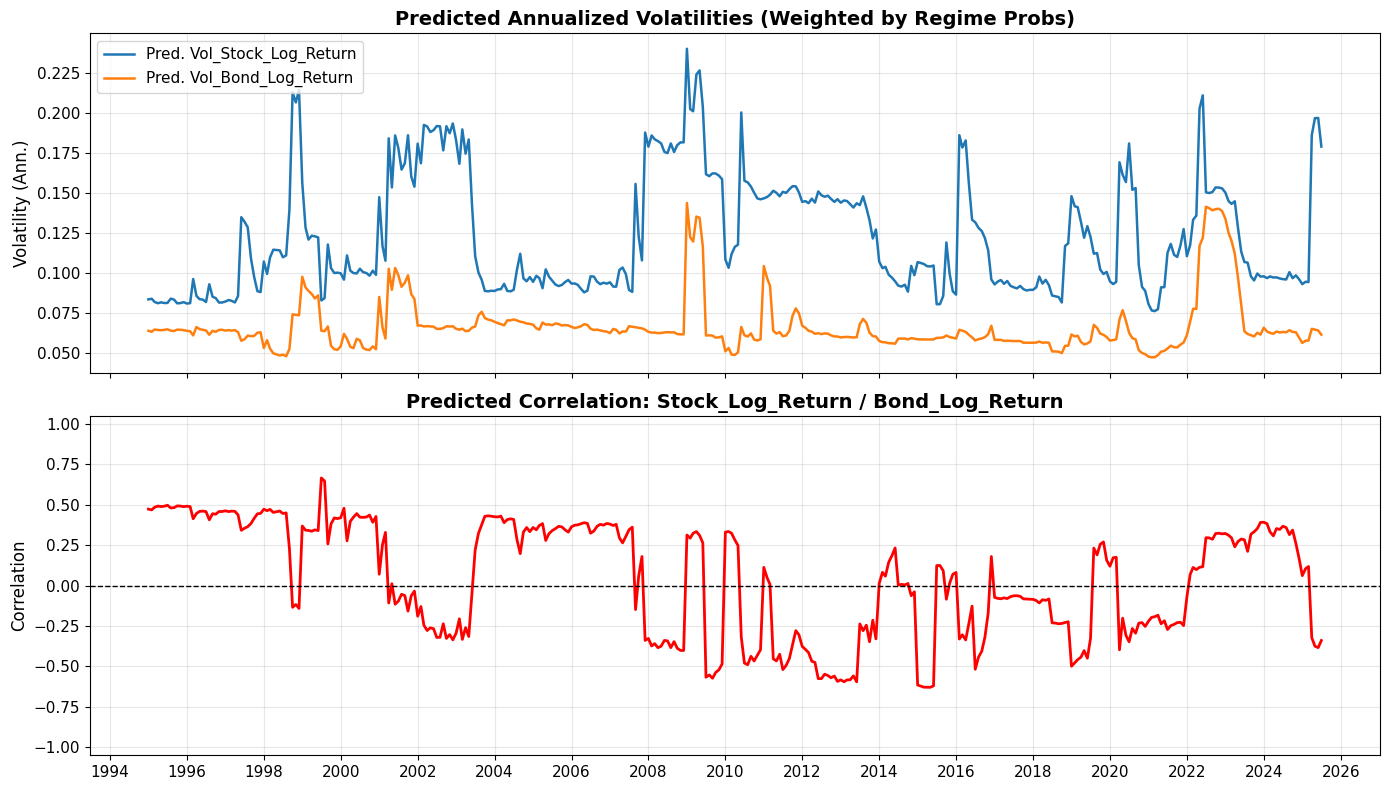

In [27]:
backtester.plot_predicted_risk_metrics()

# Backtest


FINAL STATISTICS
         IOHMM  HMM Pure  Rolling RP   60/40
Return  0.0926    0.0910      0.0704  0.0868
Vol     0.0622    0.0682      0.0564  0.0767
Sharpe  1.0780    0.9677      0.8177  0.8195
MDD    -0.1105   -0.1698     -0.1913 -0.2700
Calmar  0.8381    0.5359      0.3680  0.3216


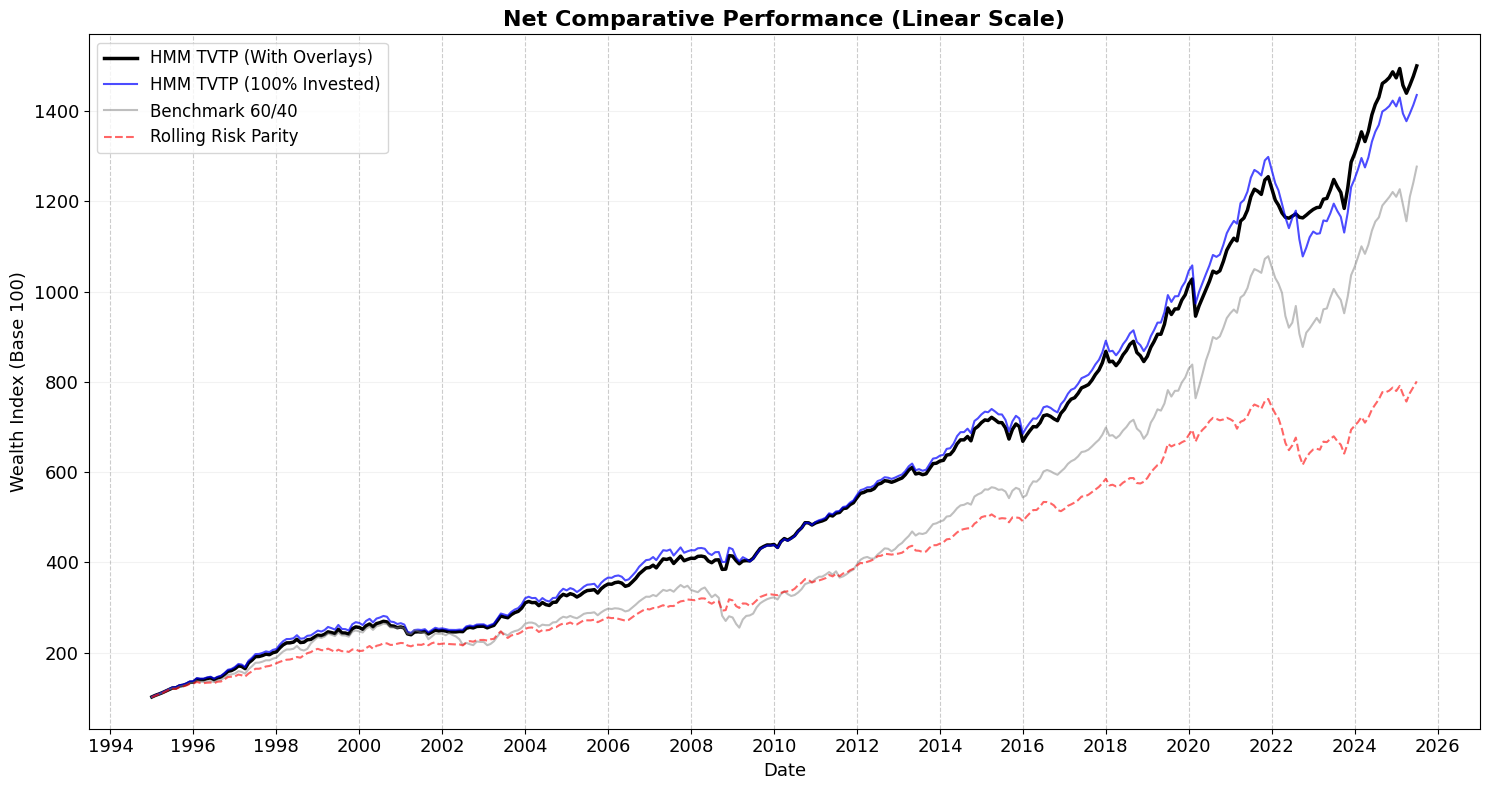

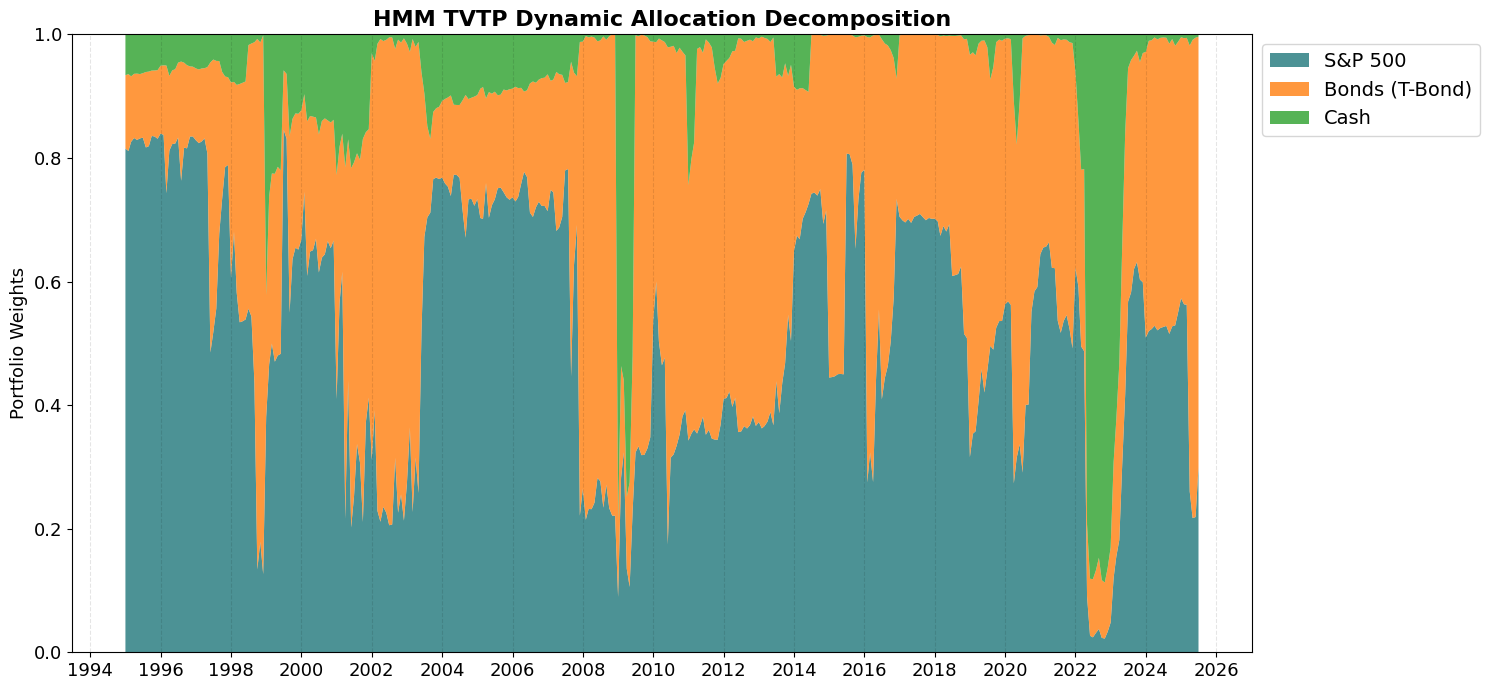

In [29]:
# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================
ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
START_YEAR = 1995

# Instantiation of the simulator with risk parameters
sim = StrategySimulator(
    target_vol=0.07,
    max_leverage=1.0,
    lev_normal=1.0,
    lev_min_stress=0.10,
    cost_per_trade=0.0010,
    borrow_spread=0.01,
    smooth_alpha=1.0
)

# =============================================================================
# 2. STRATEGY EXECUTION
# =============================================================================
results = sim.run(
    backtester=backtester,
    df=df,
    asset_vars=ASSET_VARS,
    start_year=START_YEAR,
    sp_budget_range=(0.10, 0.95)
)

# =============================================================================
# 3. PERFORMANCE ANALYSIS (METRICS)
# =============================================================================
metrics_data = {
    "IOHMM": get_metrics(results["portfolio_rets"], results["history_rf"]),
    "HMM Pure": get_metrics(results["rets_hmm_pure"], results["history_rf"]),
    "Rolling RP": get_metrics(results["rets_rp"], results["history_rf"]),
    "60/40": get_metrics(results["rets_6040"], results["history_rf"])
}

stats = pd.DataFrame(metrics_data, index=["Return", "Vol", "Sharpe", "MDD", "Calmar"])

print("\n" + "="*50)
print("FINAL STATISTICS")
print("="*50)
print(stats.round(4))

# =============================================================================
# 4. VISUALIZATION (REPORTING)
# =============================================================================
# Equity curves
plot_equity_curves(
    results,
    strategies=["portfolio_rets", "rets_hmm_pure", "rets_6040", "rets_rp"]
)

# Allocation decomposition (stackplot)
plot_allocation_stack(results)

# Explainability and Analysis

## 2008

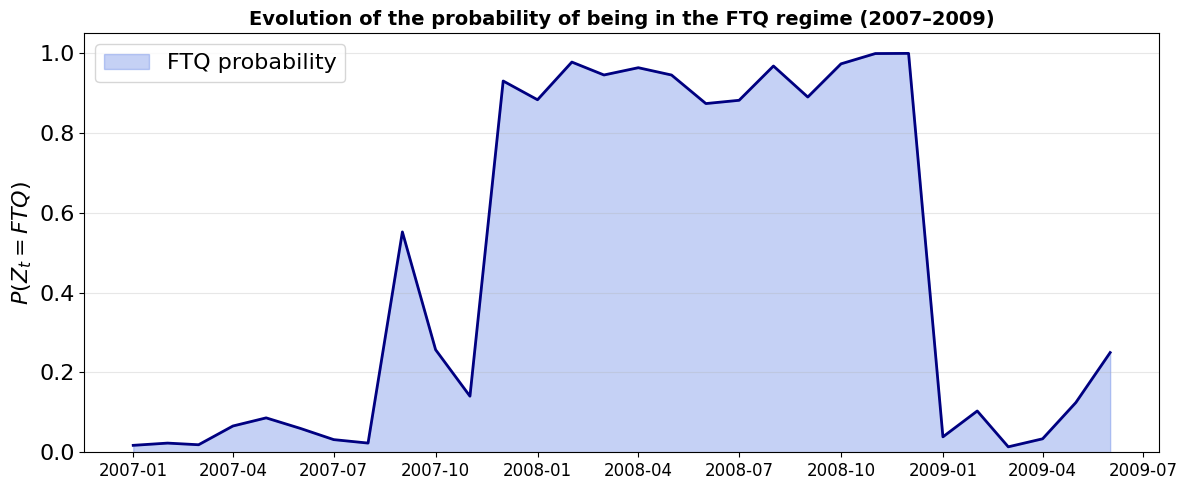

In [30]:
# 1. Extraction of backtester data
dates = sorted(backtester.regime_probs.keys())
dates = [d for d in dates if d >= pd.Timestamp("2007-01-01") and d <= pd.Timestamp("2009-06-01")]
probs_matrix = np.array([backtester.regime_probs[d] for d in dates])

# 2. Construction of a manual "FTQ probability" series
# The FTQ regime index is defined based on audit observations
ftq_probs = []

for i, d in enumerate(dates):
    p = backtester.regime_probs[d]

    # Manual mapping based on the audit:
    if d < pd.Timestamp("2009-01-01"):
        ftq_probs.append(p[2])
    else:
        ftq_probs.append(p[0])

df_ftq = pd.Series(ftq_probs, index=dates)

# 3. Plotting
plt.figure(figsize=(12, 5))
plt.fill_between(df_ftq.index, 0, df_ftq, color='royalblue', alpha=0.3, label='FTQ probability')
plt.plot(df_ftq, color='navy', lw=2)

plt.title("Evolution of the probability of being in the FTQ regime (2007–2009)", fontsize=14, fontweight='bold')
plt.ylabel(r"$P(Z_t = FTQ)$", fontsize=16)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# 2. X-axis ticks (dates)
plt.tick_params(axis='x', which='major', labelsize=12)  # adjust date labels here

# 3. Y-axis ticks (probabilities)
plt.tick_params(axis='y', which='major', labelsize=16)  # adjust probability scale here

# 4. Legend
plt.legend(fontsize=16)

plt.tight_layout()
plt.show()

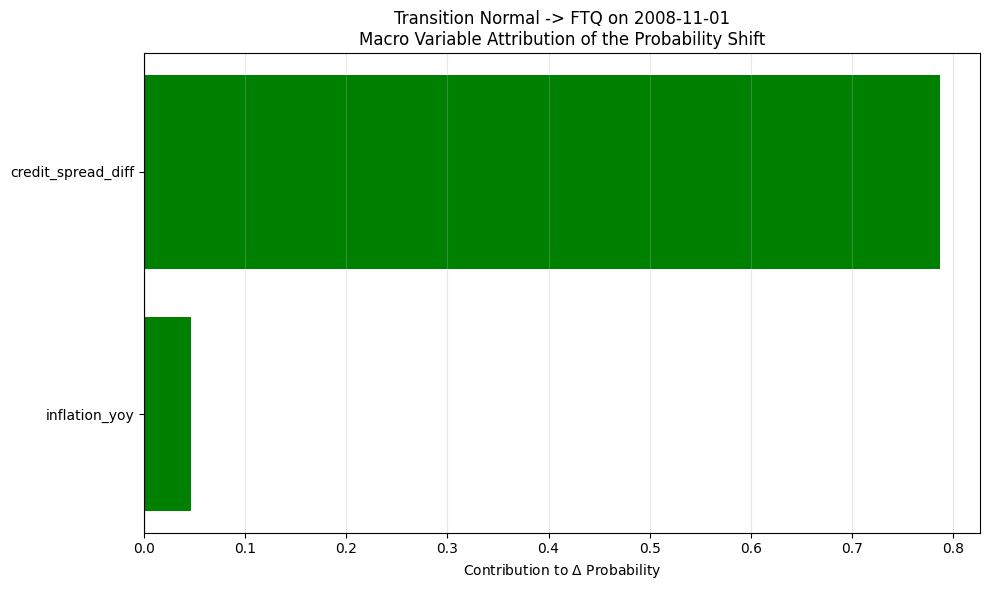

Total transition probability change: +83.38%
 Contribution of inflation_yoy        : +4.67%
 Contribution of credit_spread_diff   : +78.71%


In [31]:
# Definition of the transition window (Lehman shock)
date_t = pd.Timestamp("2008-10-01")
date_tp1 = pd.Timestamp("2008-11-01")


# 1. Retrieve the EXACT detector from November 2008
# We select the closest (earlier or equal) refit date
target_date = pd.Timestamp("2007-01-01")
refit_dates = [d for d in backtester.history_detectors.keys() if d <= target_date]
historical_detector = backtester.history_detectors[max(refit_dates)]

# 2. Initialize the explainer with this historical model
explainer = TransitionExplainer(
    detector=historical_detector,
    feature_names=backtester.input_vars
)

# 3. Preparation of macro data (causal standardization)
# The model uses Z-scores computed only on past data
def get_causal_zscore(date, df, vars):
    train_mask = (df.index < date)
    mu = df.loc[train_mask, vars].mean()
    std = df.loc[train_mask, vars].std() + 1e-9
    return (df.loc[date, vars] - mu) / std

X_t = get_causal_zscore(date_t, df, backtester.input_vars).values
X_tp1 = get_causal_zscore(date_tp1, df, backtester.input_vars).values

# 4. Transition delta explanation
# According to the audit: transition from Regime 1 (Normal) to Regime 2 (FTQ/Stress)
from_regime = 1
to_regime = 2

# Integrated Gradients attribution
attr = explainer.explain_delta(
    X_t=X_t,
    X_tp1=X_tp1,
    from_state=from_regime,
    to_state=to_regime,
    steps=100  # integration accuracy
)

# 4. Visualization
explainer.plot_explanation(
    attr,
    from_regime,
    to_regime,
    "2008-11-01",
    from_regime_name="Normal",
    to_regime_name="FTQ"
)

# --- RESULT ANALYSIS ---
total_delta = np.sum(attr)
print(f"Total transition probability change: {total_delta:+.2%}")
for name, val in zip(backtester.input_vars, attr):
    print(f" Contribution of {name:<20} : {val:+.2%}")

## 2022

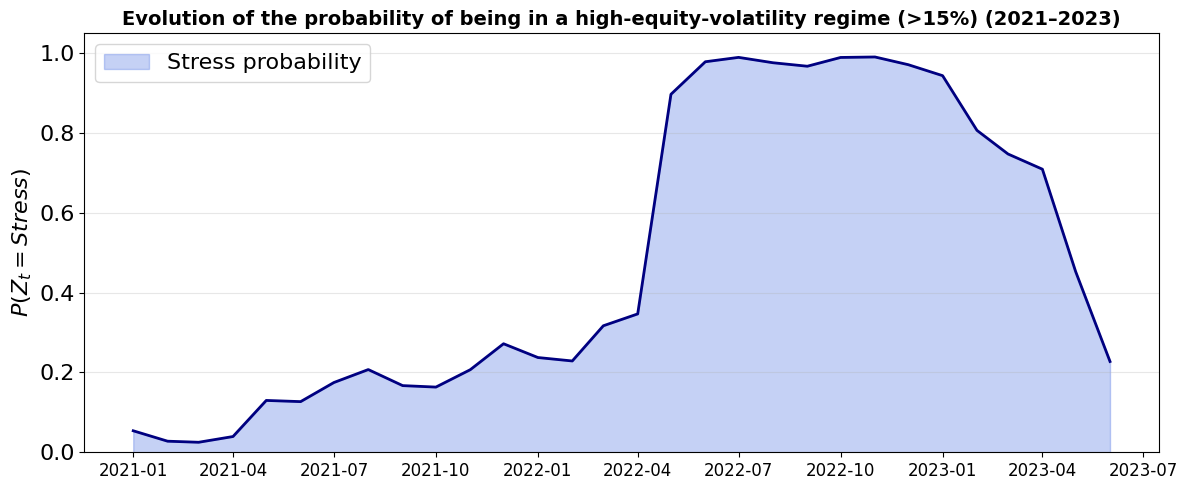

In [32]:
# 1. Extraction of backtester data
dates = sorted(backtester.regime_probs.keys())
dates = [d for d in dates if d >= pd.Timestamp("2021-01-01") and d <= pd.Timestamp("2023-06-01")]
probs_matrix = np.array([backtester.regime_probs[d] for d in dates])

# 2. Construction of a manual "FTQ probability" series
# FTQ regime index is defined based on observed audit periods
ftq_probs = []

for i, d in enumerate(dates):
    p = backtester.regime_probs[d]

    # Manual mapping based on the audit:
    if d < pd.Timestamp("2021-05-01"):
        ftq_probs.append(p[2] + p[0])

    elif d < pd.Timestamp("2022-01-01"):
        ftq_probs.append(p[2] + p[0])

    elif d < pd.Timestamp("2022-07-01"):
        ftq_probs.append(p[0] + p[2])

    elif d < pd.Timestamp("2023-01-01"):
        ftq_probs.append(p[1] + p[0])

    else:
        ftq_probs.append(p[2] + p[0])

df_ftq = pd.Series(ftq_probs, index=dates)

# 3. Plot
plt.figure(figsize=(12, 5))
plt.fill_between(df_ftq.index, 0, df_ftq, color='royalblue', alpha=0.3, label='Stress probability')
plt.plot(df_ftq, color='navy', lw=2)

plt.title("Evolution of the probability of being in a high-equity-volatility regime (>15%) (2021–2023)",
          fontsize=14, fontweight='bold')
plt.ylabel(r"$P(Z_t = Stress)$", fontsize=16)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# X-axis ticks (dates)
plt.tick_params(axis='x', which='major', labelsize=12)

# Y-axis ticks (probabilities)
plt.tick_params(axis='y', which='major', labelsize=16)

# Legend
plt.legend(fontsize=16)

plt.tight_layout()
plt.show()

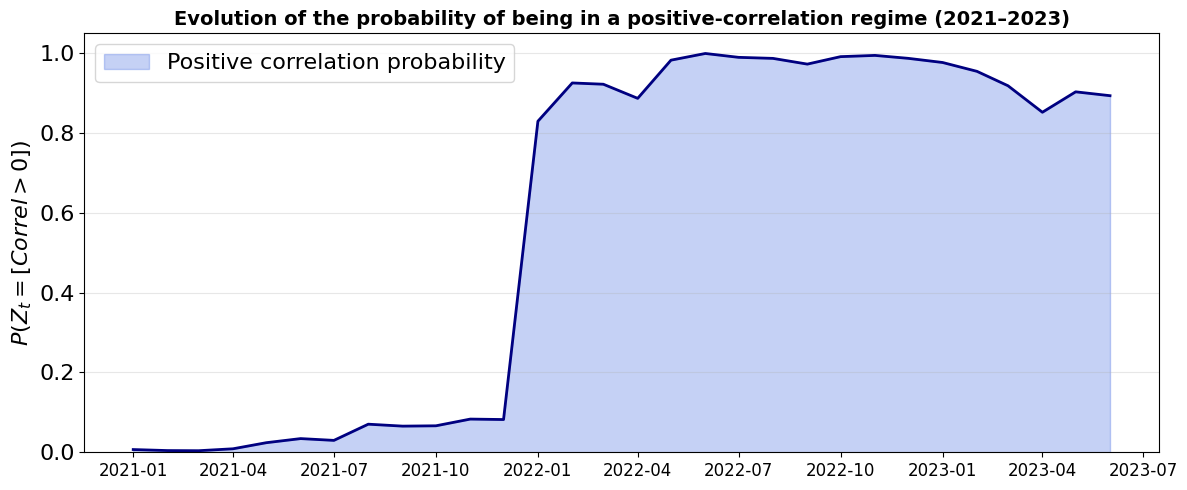

In [33]:
# 1. Extraction of backtester data
dates = sorted(backtester.regime_probs.keys())
dates = [d for d in dates if d >= pd.Timestamp("2021-01-01") and d <= pd.Timestamp("2023-06-01")]
probs_matrix = np.array([backtester.regime_probs[d] for d in dates])

# 2. Construction of a manual "FTQ probability" series
# FTQ regime index is defined based on audit observations
ftq_probs = []

for i, d in enumerate(dates):
    p = backtester.regime_probs[d]

    # Manual mapping based on the audit:
    if d < pd.Timestamp("2021-07-01"):
        ftq_probs.append(p[3] + p[0])

    elif d < pd.Timestamp("2022-01-01"):
        ftq_probs.append(p[1] + p[2])

    elif d < pd.Timestamp("2022-07-01"):
        ftq_probs.append(p[0] + p[1] + p[3])

    elif d < pd.Timestamp("2023-01-01"):
        ftq_probs.append(p[1] + p[3])

    else:
        ftq_probs.append(p[1] + p[2])

df_ftq = pd.Series(ftq_probs, index=dates)

# 3. Plot
plt.figure(figsize=(12, 5))
plt.fill_between(df_ftq.index, 0, df_ftq, color='royalblue', alpha=0.3, label='Positive correlation probability')
plt.plot(df_ftq, color='navy', lw=2)

plt.title("Evolution of the probability of being in a positive-correlation regime (2021–2023)",
          fontsize=14, fontweight='bold')
plt.ylabel(r"$P(Z_t = [Correl > 0])$", fontsize=16)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# X-axis ticks (dates)
plt.tick_params(axis='x', which='major', labelsize=12)

# Y-axis ticks (probabilities)
plt.tick_params(axis='y', which='major', labelsize=16)

# Legend
plt.legend(fontsize=16)

plt.tight_layout()
plt.show()

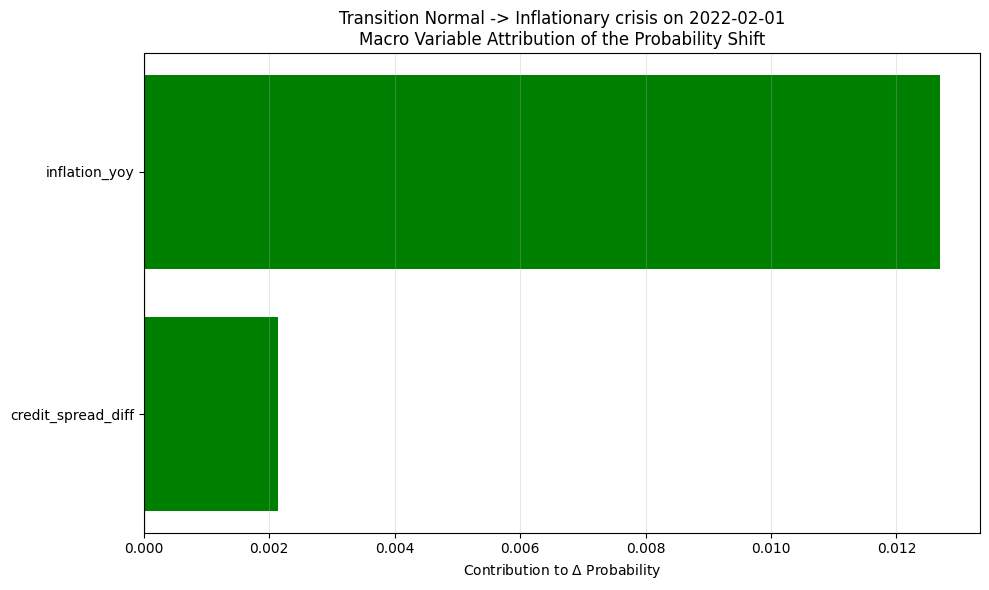

Total transition probability change: +1.48%
 Contribution of inflation_yoy        : +1.27%
 Contribution of credit_spread_diff   : +0.21%


In [34]:
# Definition of the transition window (pre-inflation shock)
date_t = pd.Timestamp("2022-01-01")
date_tp1 = pd.Timestamp("2022-02-01")


# 1. Retrieve the EXACT detector from February 2022
# We select the closest (earlier or equal) refit date
target_date = pd.Timestamp("2022-01-01")
refit_dates = [d for d in backtester.history_detectors.keys() if d <= target_date]
historical_detector = backtester.history_detectors[max(refit_dates)]

# 2. Initialize the explainer with this historical model
explainer = TransitionExplainer(
    detector=historical_detector,
    feature_names=backtester.input_vars
)

# 3. Preparation of macro data (causal standardization)
# The model uses Z-scores computed only on past data
def get_causal_zscore(date, df, vars):
    train_mask = (df.index < date)
    mu = df.loc[train_mask, vars].mean()
    std = df.loc[train_mask, vars].std() + 1e-9
    return (df.loc[date, vars] - mu) / std

X_t = get_causal_zscore(date_t, df, backtester.input_vars).values
X_tp1 = get_causal_zscore(date_tp1, df, backtester.input_vars).values

# 4. Transition delta explanation
# According to the audit: transition from Regime 1 (Normal) to Regime 0 (Inflationary crisis)
from_regime = 1
to_regime = 0


# Integrated Gradients attribution
attr = explainer.explain_delta(
    X_t=X_t,
    X_tp1=X_tp1,
    from_state=from_regime,
    to_state=to_regime,
    steps=100  # integration precision
)

# 4. Visualization
explainer.plot_explanation(
    attr,
    from_regime,
    to_regime,
    "2022-02-01",
    from_regime_name="Normal",
    to_regime_name="Inflationary crisis"
)

# --- RESULT ANALYSIS ---
total_delta = np.sum(attr)
print(f"Total transition probability change: {total_delta:+.2%}")
for name, val in zip(backtester.input_vars, attr):
    print(f" Contribution of {name:<20} : {val:+.2%}")